In [45]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Understanding the data..

In [3]:
df = pd.read_csv('insurance.csv')

In [7]:
df.shape

(1338, 7)

In [8]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [10]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [11]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [18]:
df.duplicated().sum()

np.int64(1)

In [22]:
df.drop_duplicates(inplace = True)

In [24]:
df.shape

(1337, 7)

In [25]:
df.corr(numeric_only = True)

,age,bmi,children,charges
age,1.000000,0.109344,0.041536,0.298308
bmi,0.109344,1.000000,0.012755,0.198401
children,0.041536,0.012755,1.000000,0.067389
charges,0.298308,0.198401,0.067389,1.000000


In [ ]:
df.corr(numeric_only = True)['charges']
# older people tend to have higher medical charges

age         0.298308
bmi         0.198401
children    0.067389
charges     1.000000
Name: charges, dtype: float64

### Univariate Analysis..

In [34]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


sex
male      675
female    662
Name: count, dtype: int64

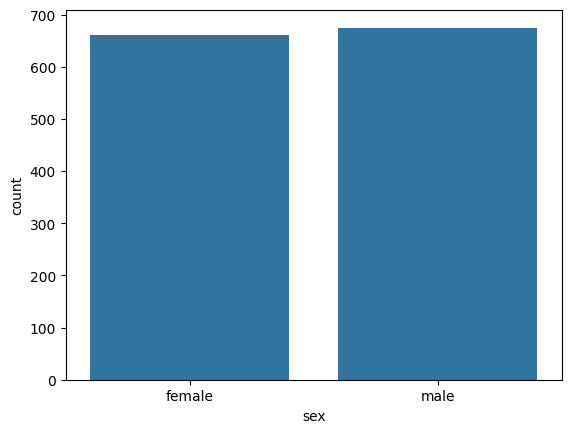

In [31]:
sns.countplot(data = df, x = 'sex')
df['sex'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

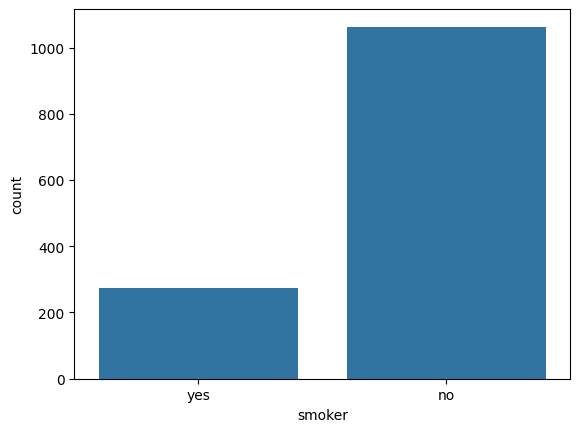

In [32]:
sns.countplot(data = df, x = 'smoker')
df['smoker'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

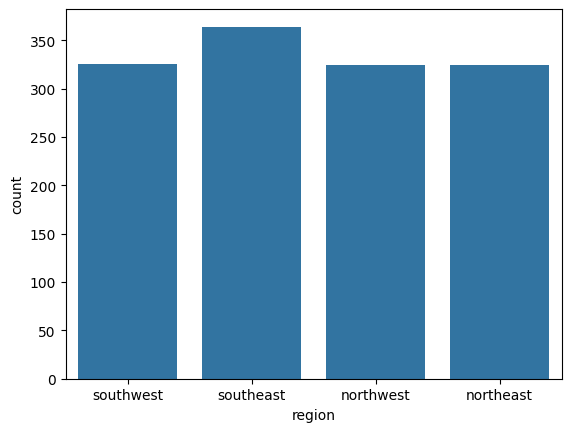

In [33]:
sns.countplot(data = df, x = 'region')
df['region'].value_counts()

Skewness of age is : 0.054780773126998195


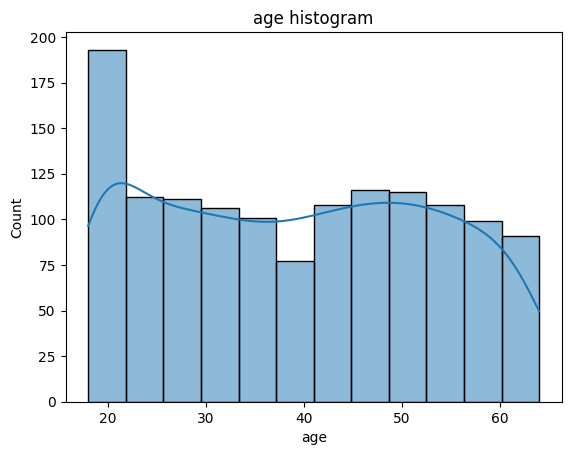

Skewness of bmi is : 0.28391419385321137


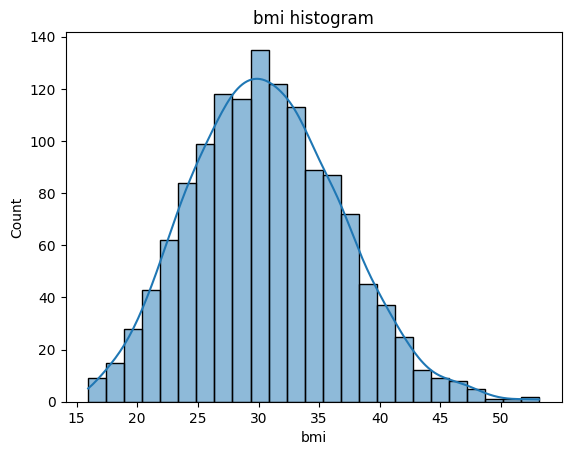

Skewness of children is : 0.9374206440474123


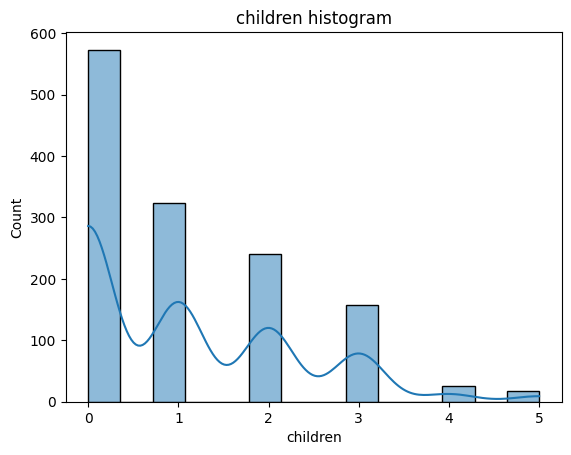

Skewness of charges is : 1.5153909108403483


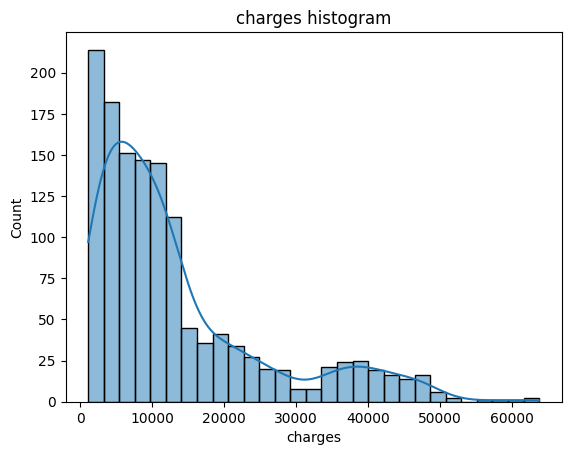

In [ ]:
num_cols = df.select_dtypes(include = ['number']).columns
for col in num_cols:
    print(f'Skewness of {col} is : {df[col].skew()}')
    sns.histplot(data = df, x = col, kde = True)
    plt.title(f'{col} histogram')
    plt.show()

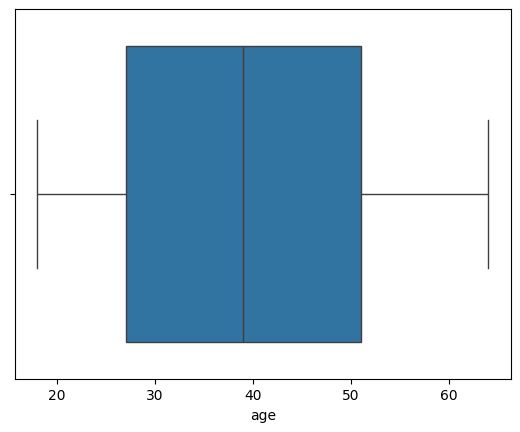

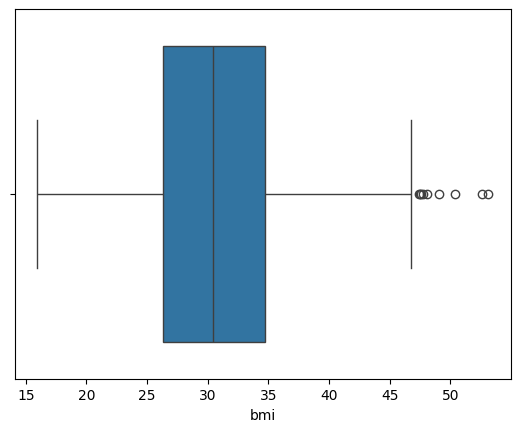

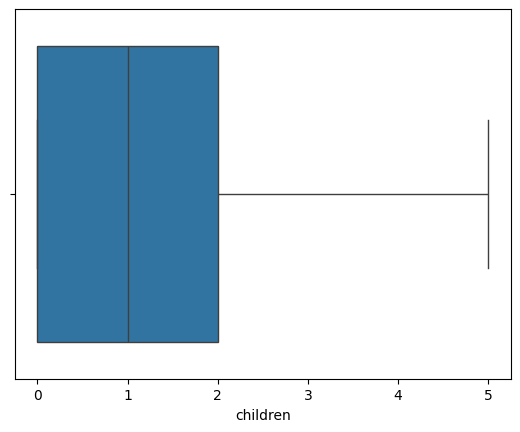

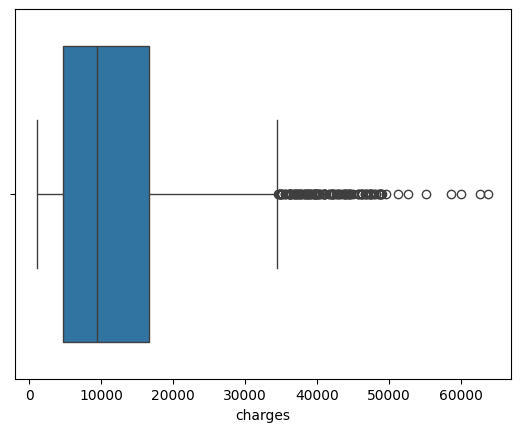

In [55]:
num_cols = df.select_dtypes(include = ['number']).columns
for col in num_cols:
    sns.boxplot(data = df, x = col)
    plt.show()

In [ ]:
df['bmi'].sort_values(ascending = False)

1317    53.130
1047    52.580
847     50.380
116     49.060
286     48.070
         ...  
1286    17.290
412     17.195
1226    16.815
428     16.815
172     15.960
Name: bmi, Length: 1337, dtype: float64

In [56]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [61]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


<Axes: xlabel='bmi', ylabel='charges'>

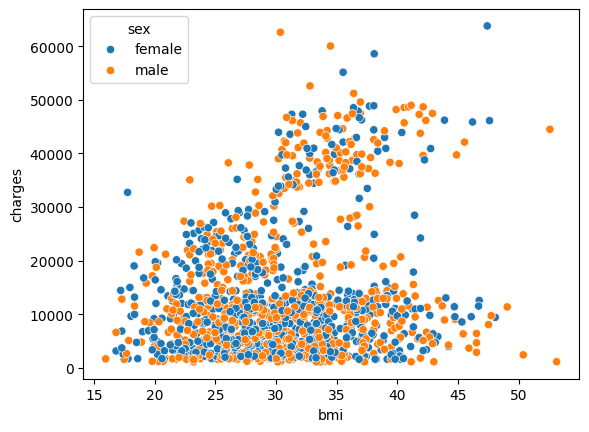

In [66]:
sns.scatterplot(data = df, x = 'bmi', y = 'charges', hue = 'sex')

<Axes: xlabel='age', ylabel='charges'>

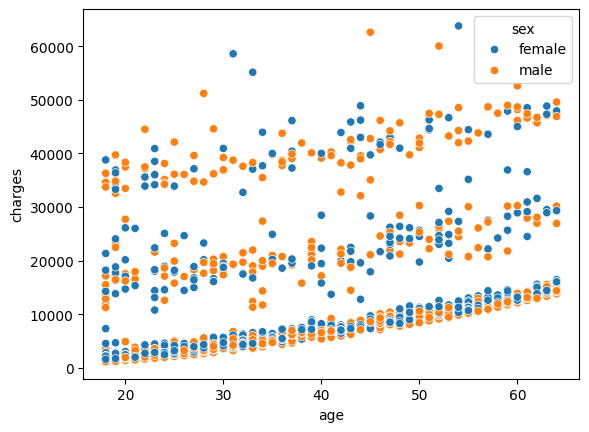

In [65]:
sns.scatterplot(data = df, x = 'age', y = 'charges', hue = 'sex')

<Axes: xlabel='smoker', ylabel='charges'>

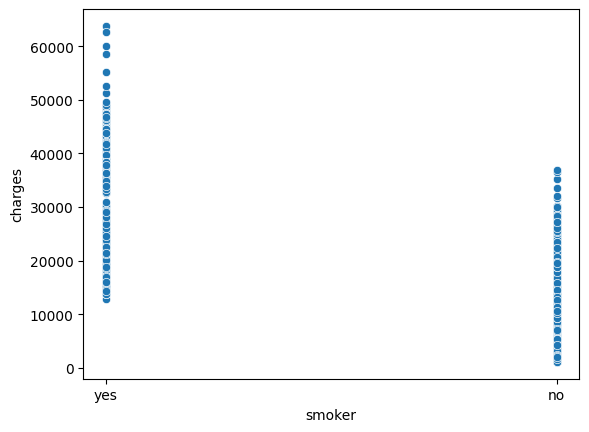

In [64]:
sns.scatterplot(data = df, x = 'smoker', y = 'charges')